In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv(
    "../data/processed/featured_delivery_data.csv"
)

In [4]:
df.head()

,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days,location,payment_method,delivery_status,high_rating,fast_shipping,popular_product
0,Sports,Cycling,Nike,13307.41,24.89,9995.09,3.2,26,308,3.5,4,Mumbai,UPI,0,0,0,0
1,Electronics,Headphones,Samsung,5464.82,15.70,4606.69,3.1,5,453,2.7,4,Mumbai,Cash on Delivery,1,0,0,0
2,Beauty,Makeup,Lenovo,3437.74,45.41,1876.51,3.7,41,222,3.5,2,Hyderabad,Debit Card,1,0,1,0
3,Home,Kitchen,H&M,7754.11,14.21,6652.29,4.1,128,479,2.9,4,Hyderabad,UPI,0,1,0,1
4,Clothing,Men,Apple,967.17,30.44,672.76,3.9,18,471,3.3,5,Delhi,Credit Card,1,0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   category            20000 non-null  str    
 1   subcategory         20000 non-null  str    
 2   brand               20000 non-null  str    
 3   price               20000 non-null  float64
 4   discount            20000 non-null  float64
 5   final_price         20000 non-null  float64
 6   rating              20000 non-null  float64
 7   review_count        20000 non-null  int64  
 8   stock               20000 non-null  int64  
 9   seller_rating       20000 non-null  float64
 10  shipping_time_days  20000 non-null  int64  
 11  location            20000 non-null  str    
 12  payment_method      20000 non-null  str    
 13  delivery_status     20000 non-null  int64  
 14  high_rating         20000 non-null  int64  
 15  fast_shipping       20000 non-null  int64  
 16  popular_product

Selecting columns to encode

In [6]:
categorical_columns = [
    "category",
    "subcategory",
    "brand",
    "location",
    "payment_method"
]

In [7]:
le = LabelEncoder()

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [8]:
df.head()

,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days,location,payment_method,delivery_status,high_rating,fast_shipping,popular_product
0,4,1,7,13307.41,24.89,9995.09,3.2,26,308,3.5,4,4,3,0,0,0,0
1,2,6,9,5464.82,15.70,4606.69,3.1,5,453,2.7,4,4,0,1,0,0,0
2,0,10,6,3437.74,45.41,1876.51,3.7,41,222,3.5,2,3,2,1,0,1,0
3,3,8,3,7754.11,14.21,6652.29,4.1,128,479,2.9,4,3,3,0,1,0,1
4,1,11,1,967.17,30.44,672.76,3.9,18,471,3.3,5,2,1,1,0,0,0


Creating x(Features) and y(Target) columns

In [9]:
X = df.drop("delivery_status", axis=1)

y = df["delivery_status"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Scaling

In [11]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [12]:
X_train.shape

(16000, 16)

In [13]:
X_test.shape

(4000, 16)

In [14]:
df.head()

,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days,location,payment_method,delivery_status,high_rating,fast_shipping,popular_product
0,4,1,7,13307.41,24.89,9995.09,3.2,26,308,3.5,4,4,3,0,0,0,0
1,2,6,9,5464.82,15.70,4606.69,3.1,5,453,2.7,4,4,0,1,0,0,0
2,0,10,6,3437.74,45.41,1876.51,3.7,41,222,3.5,2,3,2,1,0,1,0
3,3,8,3,7754.11,14.21,6652.29,4.1,128,479,2.9,4,3,3,0,1,0,1
4,1,11,1,967.17,30.44,672.76,3.9,18,471,3.3,5,2,1,1,0,0,0


Training

In [15]:
knn = KNeighborsClassifier(n_neighbors=5)

In [16]:
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Prediction

In [17]:
y_pred = knn.predict(X_test)

Accuracy Test

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6435


Confusion Matrix

In [19]:
conf_matrix = confusion_matrix(y_test, y_pred)

print(conf_matrix)

[[2400  444]
 [ 982  174]]


Classification report

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.84      0.77      2844
           1       0.28      0.15      0.20      1156

    accuracy                           0.64      4000
   macro avg       0.50      0.50      0.48      4000
weighted avg       0.59      0.64      0.60      4000



Model Tuning(Checking for the best K)

In [21]:
accuracy_scores = []

for k in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    accuracy_scores.append(accuracy)

    print(f"K={k}, Accuracy={accuracy}")

K=1, Accuracy=0.5785
K=2, Accuracy=0.66575
K=3, Accuracy=0.61325
K=4, Accuracy=0.67625
K=5, Accuracy=0.6435
K=6, Accuracy=0.6815
K=7, Accuracy=0.65975
K=8, Accuracy=0.68675
K=9, Accuracy=0.674
K=10, Accuracy=0.6925
K=11, Accuracy=0.6825
K=12, Accuracy=0.698
K=13, Accuracy=0.68925
K=14, Accuracy=0.701
K=15, Accuracy=0.694
K=16, Accuracy=0.70125
K=17, Accuracy=0.69775
K=18, Accuracy=0.7055
K=19, Accuracy=0.7
K=20, Accuracy=0.7055


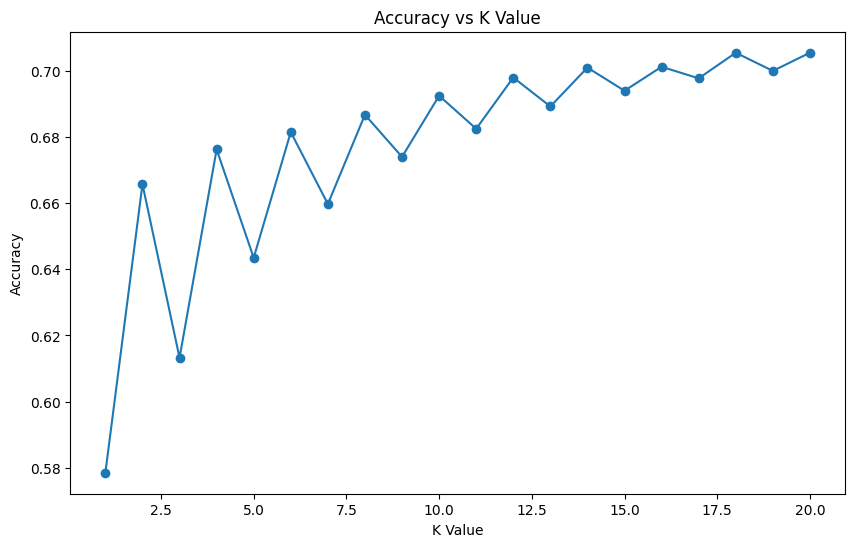

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(range(1, 21), accuracy_scores, marker='o')

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.title("Accuracy vs K Value")

plt.show()

In [23]:
knn = KNeighborsClassifier(n_neighbors=18)

In [24]:
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",18
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [25]:
y_pred = knn.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7055


In [27]:
conf_matrix = confusion_matrix(y_test, y_pred)

print(conf_matrix)

[[2803   41]
 [1137   19]]


In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.99      0.83      2844
           1       0.32      0.02      0.03      1156

    accuracy                           0.71      4000
   macro avg       0.51      0.50      0.43      4000
weighted avg       0.60      0.71      0.60      4000



“While larger K values improved overall accuracy, they significantly reduced the model’s ability to detect delayed deliveries. Therefore, K=5 was retained to maintain a more balanced classification performance.”